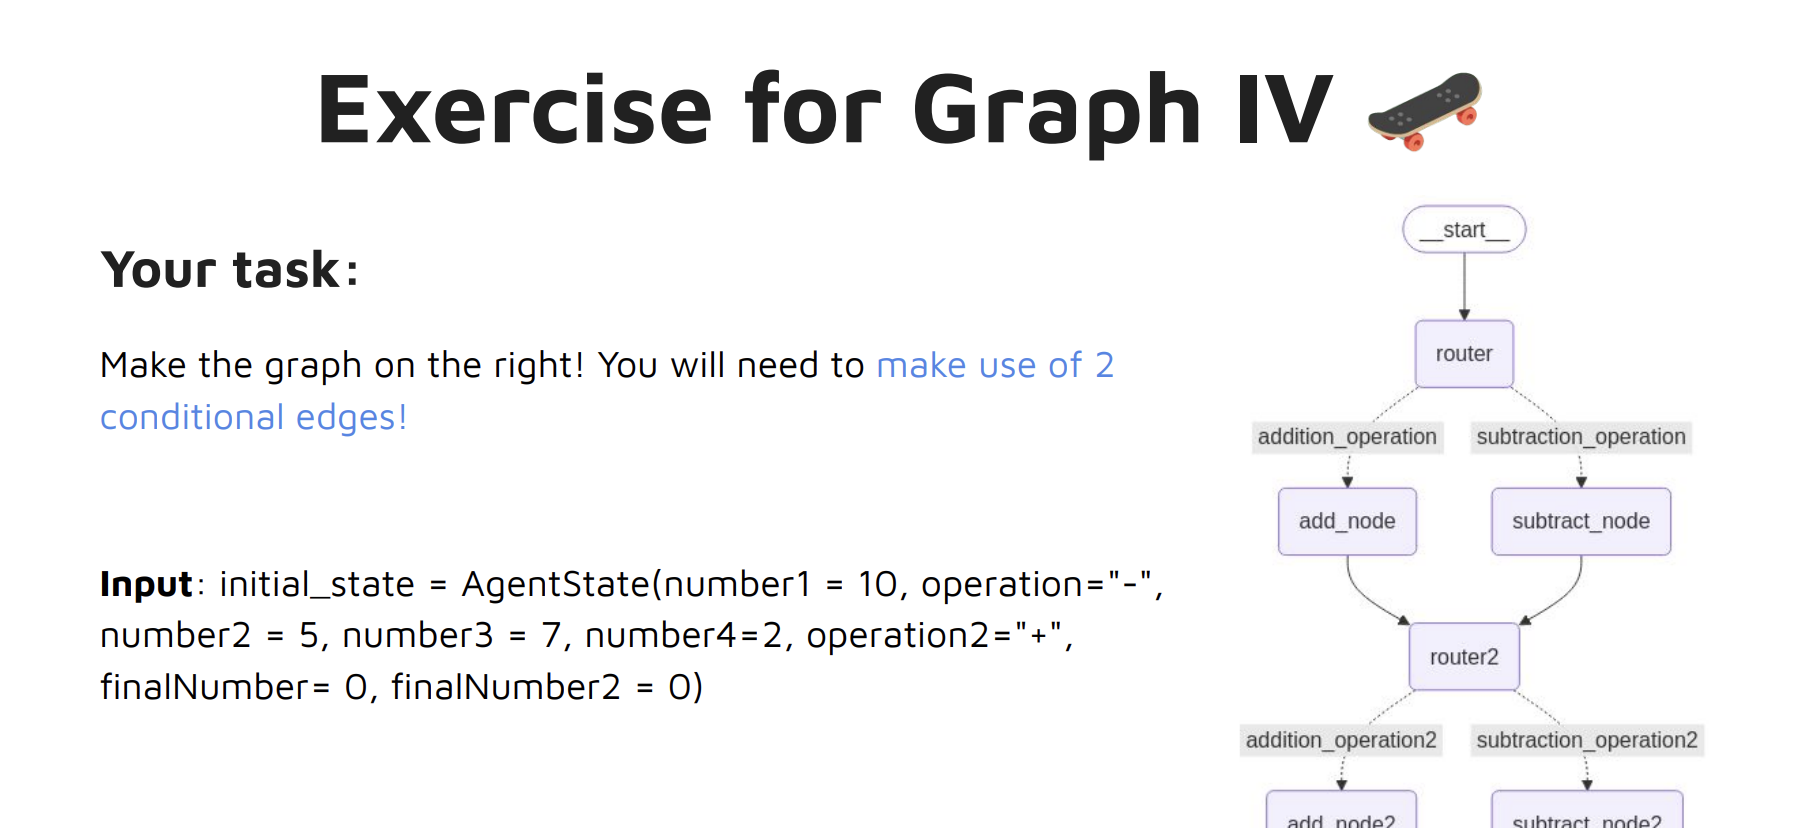

In [9]:

from IPython.display import Image
Image("graph4.png")


In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [70]:
#defining the state

class AgentState(TypedDict):
    num1: int
    op1: str
    num2: int
    num3: int
    num4:int
    op2: str
    fnum1: int
    fnum2: int
    

In [71]:
##nodes

def addition_node1(state: AgentState)->AgentState:
    """
    this node will add two numbers - num1 & num2
    """

    state['fnum1'] = state['num1']+state['num2']

    return state

def addition_node2(state: AgentState)->AgentState:
    """
    this node will add two numbers - num3 & num4
    """

    state['fnum2'] = state['num3']+state['num4']

    return state


def subt_node1(state: AgentState)->AgentState:
    """
    this node will subt two numbers - num1 & num2
    """

    state['fnum1'] = state['num1']-state['num2']

    return state

def subt_node2(state: AgentState)->AgentState:
    """
    this node will subt two numbers - num3 & num4
    """

    state['fnum2'] = state['num3']-state['num4']

    return state


def router_decision1(state: AgentState)->AgentState:
    """
    this node will be 1st router
    """

    if state['op1']=='+':
        return 'add'

    else:
        return 'subt'

def router_decision2(state: AgentState)->AgentState:
    """
    this node will be 2nd router
    """

    if state['op2']=='+':
        return 'add'

    else:
        return 'subt'


In [72]:
graph = StateGraph(AgentState)

In [73]:
graph.add_node('add_node1',addition_node1)
graph.add_node('add_node2',addition_node2)
graph.add_node('subt_node1',subt_node1)
graph.add_node('subt_node2',subt_node2)

In [74]:
##router nodes
graph.add_node('router1',lambda state:state) # a node which does nothing
graph.add_node('router2',lambda state:state)

In [75]:
##create edges

graph.add_edge(START, 'router1')
graph.add_conditional_edges('router1',router_decision1,{'add':'add_node1','subt':'subt_node1'})
graph.add_edge('add_node1','router2')
graph.add_edge('subt_node1','router2')


graph.add_conditional_edges('router2',router_decision2, {'add':'add_node2','subt':'subt_node2'})
graph.add_edge('add_node1',END)
graph.add_edge('subt_node1',END)

In [ ]:
graph.add_conditional_edges(

In [76]:
app = graph.compile()

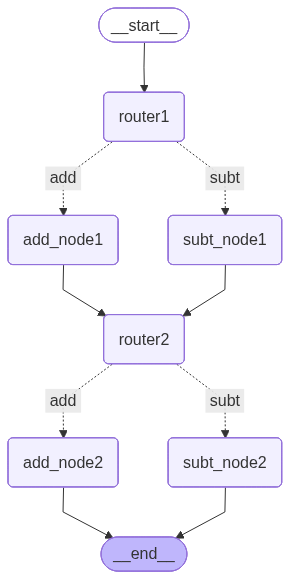

In [77]:
app

In [78]:
response = app.invoke({'num1':3,'op1':'+','num2':4,'num3':8,'num4':5,'op2':'-'})

In [79]:
response

{'num1': 3,
 'op1': '+',
 'num2': 4,
 'num3': 8,
 'num4': 5,
 'op2': '-',
 'fnum1': 7,
 'fnum2': 3}